### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 7</center>
---

### Overview

The first objective of this exercise is to continue studying spatial smoothing filters. The second objective is to study the fundamentals of the differentiation of images. Besides some other test images, the following images can be used for a systematic analysis of the differentiation.

<table>
<tr style="font-weight:bold;">
    <td>Name</td>
    <td>Image</td>
    <td>Characteristics</td>
</tr>
<tr>
    <td>h-pattern.png</td>
    <td><img src="images/h-pattern.png" /></td>
    <td>Different gray-level profiles</td>
</tr>
<tr>
    <td>h-gradient-s00.png</td>
    <td><img src="images/h-gradient-s00.png" /></td>
    <td>Gray-level ramp</td>
</tr>
<tr>
    <td>h-gradient-s01.png</td>
    <td><img src="images/h-gradient-s01.png" /></td>
    <td>Gray-level ramp with additional Gaussian noise (sigma = 1.0)</td>
</tr>
<tr>
    <td>h-gradient-s10.png</td>
    <td><img src="images/h-gradient-s10.png" /></td>
    <td>Gray-level ramp with additional Gaussian noise (sigma = 10.0)</td>
</tr>
</table>

All of these images have the same size of $30 \times 300$ pixel.

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import time

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

### <span style="color: RoyalBlue; font-weight: bold;">Task 7.1</span> Gaussian Filter Masks (smoothing filter)

In 2D, an isotropic (i. e. circularly symmetric) Gaussian centered at $(x,y) = (0,0)$ has the form:

$$
G(x, y) = K e^{-\dfrac{x^2 + y^2}{2 \sigma^2}}
\hspace{1cm}\mathrm{or}\hspace{1cm}
G(r) = K e^{-\dfrac{r^2}{2 \sigma^2}}
$$

In this equation, $r$ is the distance from the center of the mask. As the mask (or the final filtering result) is usually normalized (to equal the intensity and to avoid bias) by the sum of the coefficients, the constant $K$ can be set to 1 (instead of $1/2\pi\sigma^2$). At a distance larger than $3\sigma$ from the mean, the values of the Gaussian are so small that they can be ignored. Therefore, the size of a Gaussian kernel can be chosen as $\lceil 6\sigma\rceil \times \lceil 6\sigma \rceil$, rounded to the next odd integer (e.g., 7 for $\sigma = 1$). In practice, it is often sufficient to use $\lceil 3\sigma\rceil \times \lceil 3\sigma \rceil$.

For the filtering, you can use the function `filter_image` from the last exercise or the OpenCV function <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04">`filter2D` ↗</a>.

1. Write a function to create a Gaussian filter mask with the size $\lceil 3\sigma\rceil \times \lceil 3\sigma \rceil$ (see above).
2. Plot the mask coefficients of the middle row (or column) for different values of $\sigma$.
3. Test the function for the image *testpattern-512.png* for $\sigma = 1, 3, 7$. Plot and analyze the results.

In [2]:
# compute gaussian mask of odd size with ⌈3*sigma⌉ x ⌈3*sigma⌉
def gaussian_mask(sigma):
    # compute mask size
    sz = int(np.ceil(3 * sigma)) # ceil rounds up
    if (sz % 2 == 0): # true if sz is even
        sz = sz + 1 # closest odd integer
        
    # create mask
    print("sigma = " + str(sigma) + ", Mask size: " + str(sz))
    g = np.zeros(shape=[sz, sz], dtype=np.float64) # init with zeros
    
    # fill mask
    c = int(sz / 2) # center coordinates
    
    for iy in range(sz):
        for jx in range(sz):
            r2 = (iy-c)**2 + (jx-c)**2 # distance to the center
            g[iy, jx] = np.exp(-r2 / (2 * (sigma**2)))
            
    return g, sz


sigma = 7.0, Mask size: 21


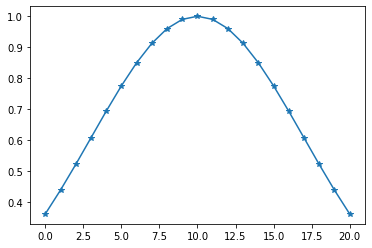

In [3]:
# plot middle row of the Gaussian for different sigma
g, sz = gaussian_mask(7.0)
plt.plot(g[int(sz/2),:], marker='*')
#plt.plot(g[3,:], marker='*'), plot only 3rd row, there the max lies.
plt.show()

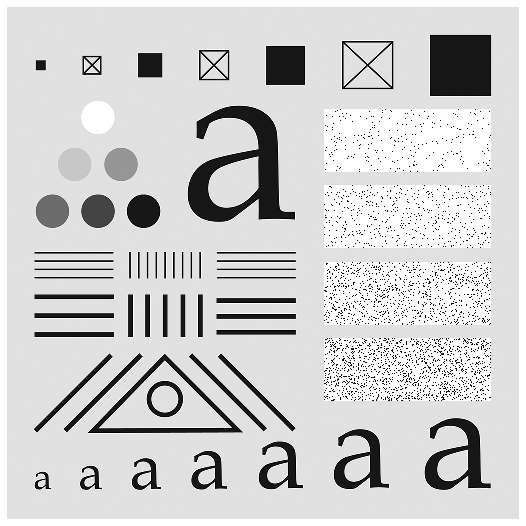

In [4]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/testpattern-512.png', 0)
plot_img_orig(img)

sigma = 1.0, Mask size: 3


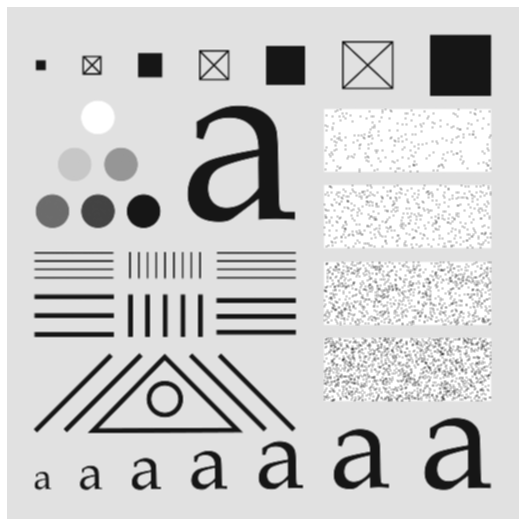

In [5]:
# filter the image with normalized masks
# sigma = 1.0
g, sz = gaussian_mask(1.0)
res_s01 = cv2.filter2D(img, cv2.CV_64F, g/np.sum(g)) #gaussian is normalized to 1. 
plot_img_orig(res_s01)

sigma = 3.0, Mask size: 9


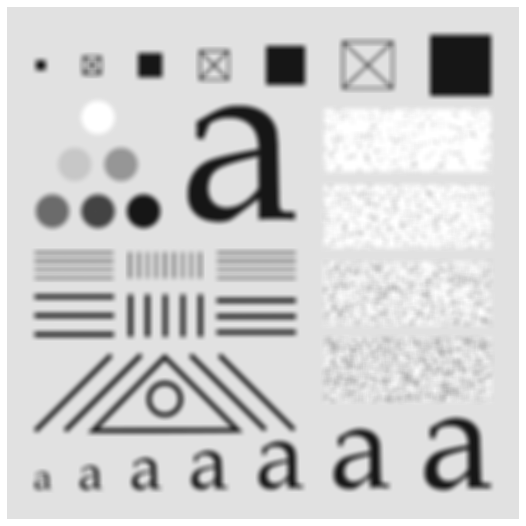

In [6]:
# sigma = 3.0
g, sz = gaussian_mask(3.0)
res_s03 = cv2.filter2D(img, cv2.CV_64F, g/np.sum(g))
plot_img_orig(res_s03)

sigma = 7.0, Mask size: 21


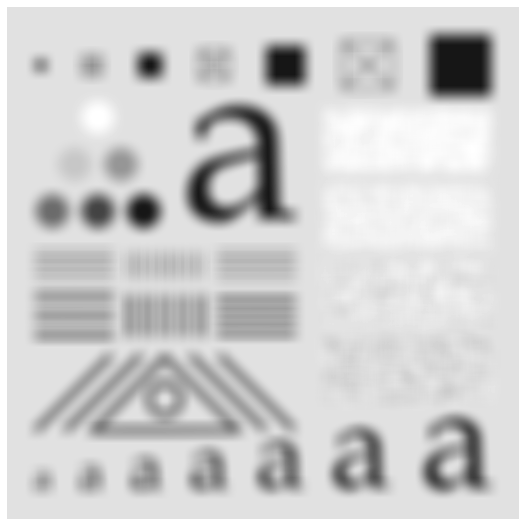

In [7]:
# sigma = 7.0
g, sz = gaussian_mask(7.0)
res_s07 = cv2.filter2D(img, cv2.CV_64F, g/np.sum(g))
plot_img_orig(res_s07)

### <span style="color: RoyalBlue; font-weight: bold;">Task 7.2</span> Comparison of Gaussian and Box Filters

Gaussian filters and box filters have different smoothing characteristics, of which some of them are not apparent at first glance. The objective of this task is to study these differences. For the box filters, you can use the function `mean_filter` from the last exercise or the OpenCV function <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga8c45db9afe636703801b0b2e440fce37">`blur` ↗</a>.

Implement / solve the following tasks:
1. Compare the results of the mean (average) filter when using the same filter sizes as in the previous task for the image *testpattern-512.png*.
2. Compare the results for the image *white-bar.png* for a filter size of $25 \times 25$.
3. Plot and compare the intensity profiles along the middle row of the filtered images.

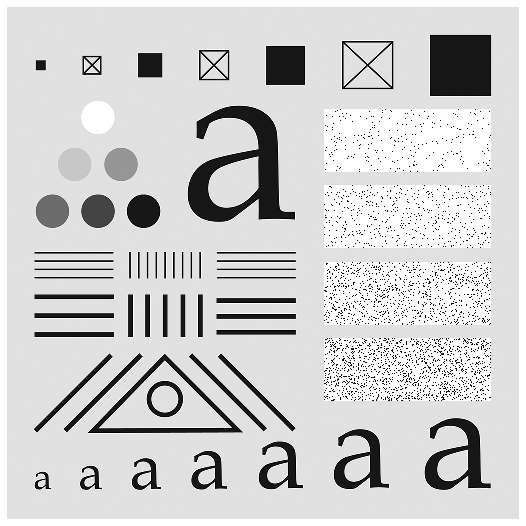

In [8]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/testpattern-512.png', 0)
plot_img_orig(img)

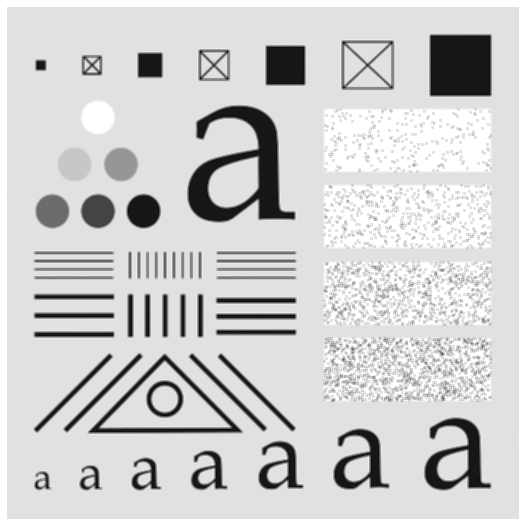

In [9]:
# mask sizes of 3x3
box_3_3 = cv2.blur(img, (3, 3))
plot_img_orig(box_3_3)

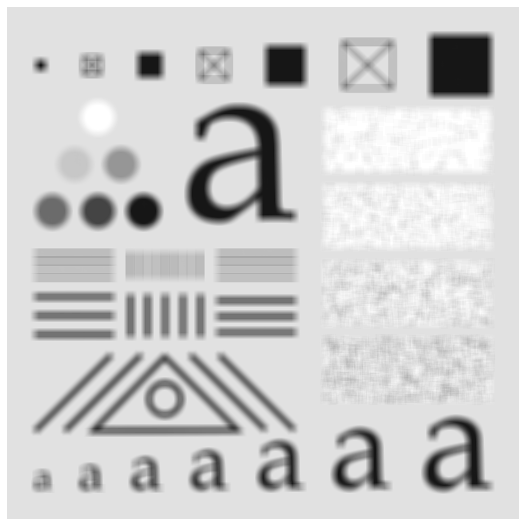

In [10]:
# mask sizes of 9x9
box_9_9 = cv2.blur(img, (9, 9))
plot_img_orig(box_9_9)

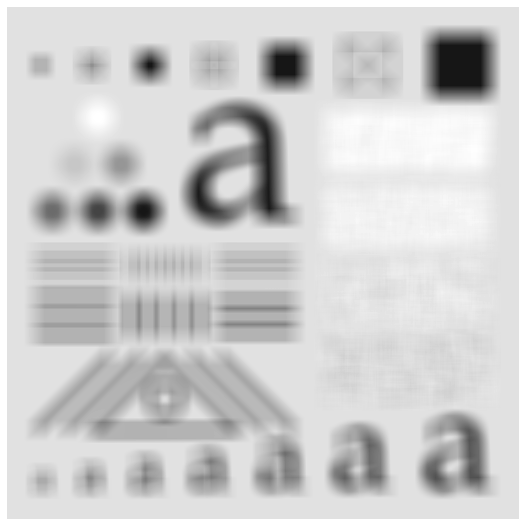

In [11]:
# mask sizes of 21x21
box_21_21 = cv2.blur(img, (21, 21))
plot_img_orig(box_21_21)

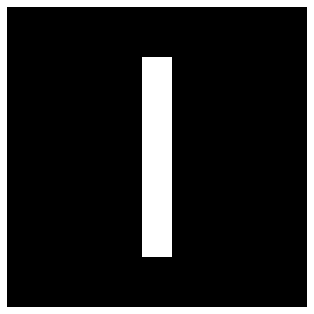

In [12]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/white-bar.png', 0)
plot_img_orig(img)

sigma = 8.0, Mask size: 25


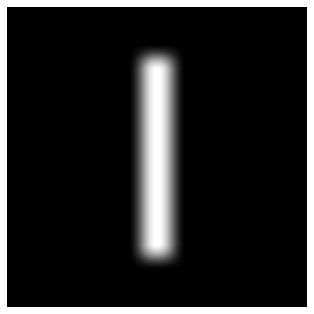

In [13]:
# 25 x 25 Gaussian
g, sz = gaussian_mask(8.0)
res_s08 = cv2.filter2D(img, cv2.CV_64F, g/np.sum(g))
plot_img_orig(res_s08)

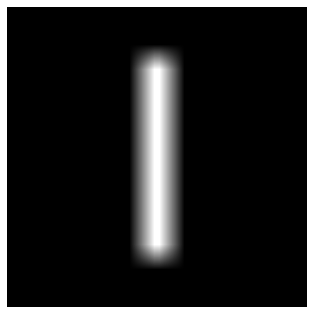

In [14]:
# 25 x 25 box filter
box_25_25 = cv2.blur(img, (25, 25))
plot_img_orig(box_25_25)

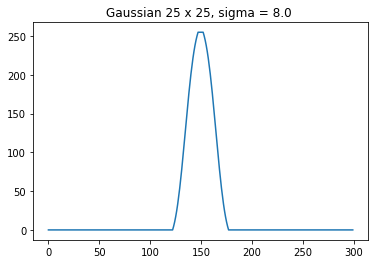

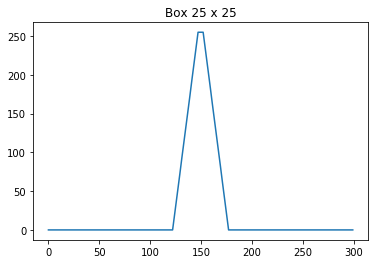

In [15]:
# plot the intensity profiles
plt.plot(res_s08[150,:]) #middle row of the image, could be 120 as well
plt.title("Gaussian 25 x 25, sigma = 8.0 ")
plt.show()

plt.plot(box_25_25[150,:])
plt.title("Box 25 x 25")
plt.show()

When using $\lceil 6\sigma\rceil \times \lceil 6\sigma \rceil$ for the size of the Gaussian masks, they have to be larger than box filters to achieve a similar amount of blurring. This is because the coefficients of the Gaussian are decreasing for larger distances. For $\lceil 3\sigma\rceil \times \lceil 3\sigma \rceil$, the amount is comparable.

As the intensity profiles show, the box filter leads to a response with the shape of a ramp, while the Gaussian mask yields to a smoother response. Depending on the specific task, this or the other method may be more suitable.

### <span style="color: RoyalBlue; font-weight: bold;">Task 7.3</span> Ranking (Median) Filter

Ranking filters (also referred to as order-statistics filters) are non-linear spatial filters whose response is based on ranking the pixels contained in the image area encompassed by the filter, and then replacing the value of the center pixel with the value determined by the ranking result. The best-known example in this category is the median filter. Median filters can effectively reduce noise with less blurring than linear filters. A drawback of median filters is that they are computationally expensive due to the sorting.

Implement / solve the following tasks:
1. Write a function for median filtering a given image corresponding to a $n\times n$ mask ($n$ should be odd) using reflection padding. You can use <a href="https://numpy.org/doc/stable/reference/generated/numpy.sort.html">`sort` ↗</a> from Numpy for sorting.
2. Test the function for the images *lena-noise-1.png* and *lena-noise-2.png* for $n = 3, 9$. Plot and analyze the results.

*Note*: The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d4/d86/group__imgproc__filter.html#ga564869aa33e58769b4469101aac458f9">`medianBlur` ↗</a>.

In [16]:
# median filter given image corresponding to n x n mask/window (n must be odd)
def median_filter(img, n):
    # compute offset / padding size
    b = int(n / 2)
    
    # compute middle index of sorted array/window
    k = int(n**2 / 2)
    
    # reflection padding
    img_pad = cv2.copyMakeBorder(img, b, b, b, b, cv2.BORDER_REFLECT_101)
    
    # size of padded image
    rows, cols = img_pad.shape
    
    # result image
    res = np.zeros(shape=[rows, cols], dtype=np.uint32) # note the data type (0 to 4294967295)
    
    # median filtering
    for iy in range(b, rows-b):
        for jx in range(b, cols-b):
            # get local neighborhood
            nbh = img_pad[iy-b:iy+b+1, jx-b:jx+b+1]
            
            # compute the median
            nbh = nbh.flatten() # makes it 1d array
            nbh = np.sort(nbh)

            # assign median
            res[iy, jx] = nbh[k]
    
    # remove extra border
    res = res[b:rows-b, b:cols-b]
    
    # return final result
    return res

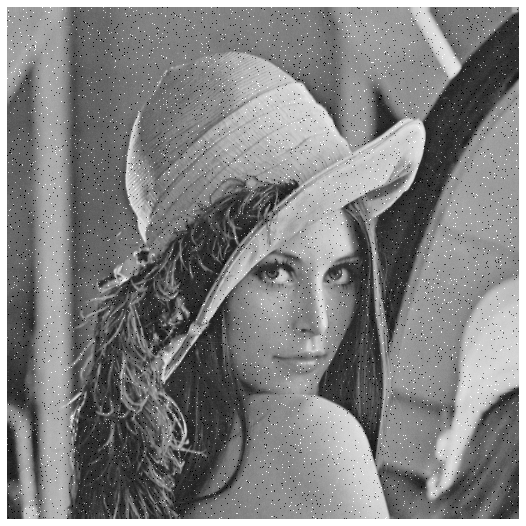

In [17]:
# read the image 'lena-noise-1' as grayscale images (parameter 0)
img1 = cv2.imread('images/lena-noise-1.png', 0)
plot_img_orig(img1)

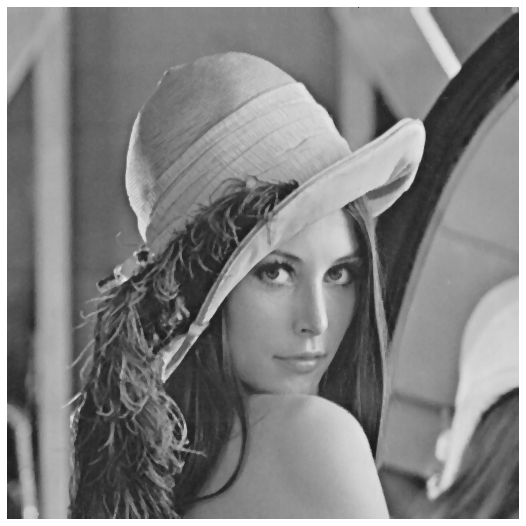

In [18]:
# median filtering 3x3
img1_med_3_3 = median_filter(img1, 3)
plot_img_orig(img1_med_3_3)

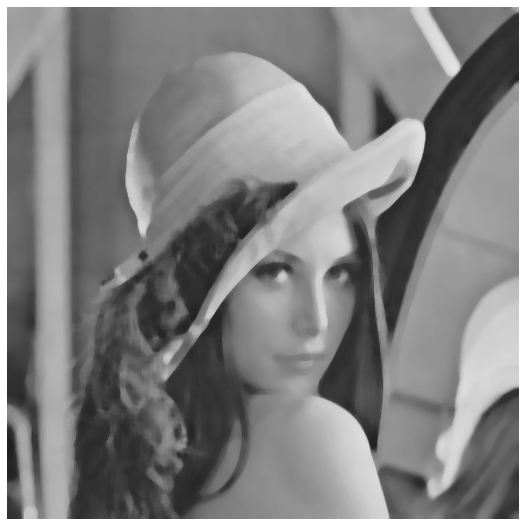

In [19]:
# median filtering 9x9
img1_med_9_9 = median_filter(img1, 9)
plot_img_orig(img1_med_9_9)

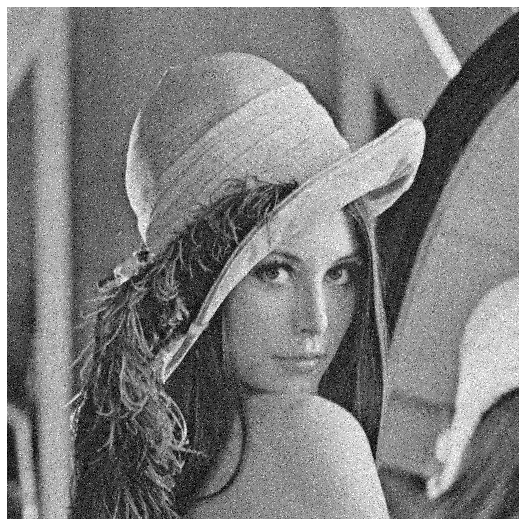

In [20]:
# read the image 'lena-noise-2.png' as grayscale images (parameter 0)
img2 = cv2.imread('images/lena-noise-2.png', 0)
plot_img_orig(img2)

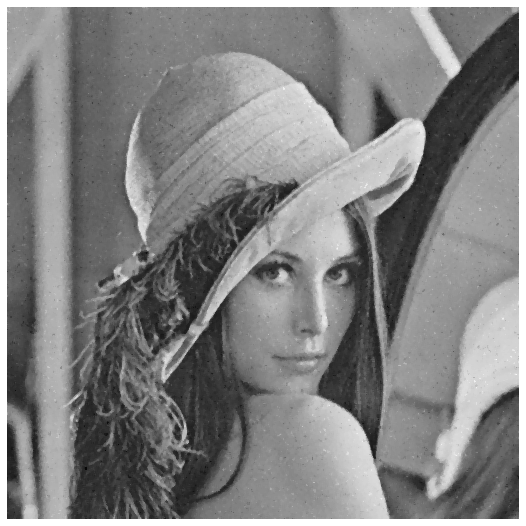

In [21]:
# median filtering 3x3
img2_med_3_3 = median_filter(img2, 3)
plot_img_orig(img2_med_3_3)

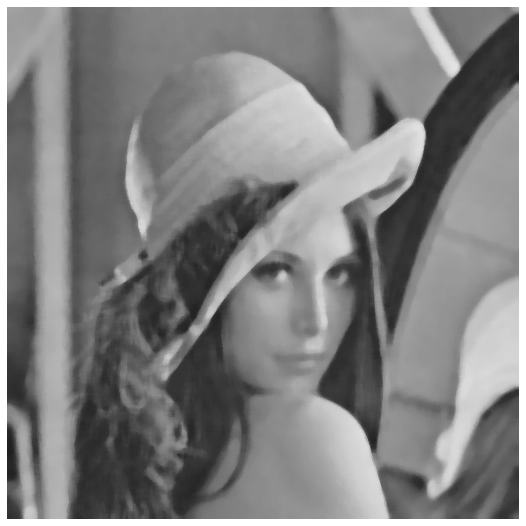

In [22]:
# median filtering 9x9
img2_med_9_9 = median_filter(img2, 9)
plot_img_orig(img2_med_9_9)

Even for an extreme amount of noise, the images are significantly enhanced. In comparison to linear smoothing filters, the result is much less blurred.

### <span style="color: RoyalBlue; font-weight: bold;">Task 7.4</span> Differentiation of Images

Since averaging is analogous to integration, it is logical to conclude that sharpening can be accomplished by spatial differentiation. In general, the strength of the response of a derivative operator is proportional to the degree of discontinuity of the point at which the operator is applied. As a result, edges and other discontinuties (also noise) are emphasized, while constant or slowly varying gray-level values are deemphasized. The first and second order derivatives of a one-dimensional function $f(x)$ are often defined as follows:

$$
\dfrac{\partial f}{\partial x} = f(x+1) - f(x)
\hspace{1cm}\mathrm{and}\hspace{1cm}
\dfrac{\partial^2 f}{\partial x^2} = f(x+1) + f(x-1) - 2f(x)
$$

Implement / solve the following tasks:
1. Write a function to compute the first and second order derivatives of a given image in the horizontal direction (along the columns). The border can just be left out.
2. Use this function to compute the derivatives for the four test images from the overview.
3. Plot and analyze the result images. It might be necessary to normalize the resulting images (you can use the OpenCV function <a href="https://docs.opencv.org/4.2.0/d2/de8/group__core__array.html#ga87eef7ee3970f86906d69a92cbf064bd">`normalize` ↗</a> for this).
4. Plot and analyze the intensity profiles along the middle row for the unnormalized and normalized images.

In [23]:
# compute 1st and 2nd derivatives in horizontal direction (along the cols)
def compute_derivatives(img):
    rows, cols = img.shape # image size
    
    img = img.astype(np.float64) # returns copy of the array, cast to the specified type

    # empty images for the results
    img_d1 = np.zeros(shape=[rows, cols], dtype=np.float64)
    img_d2 = np.zeros(shape=[rows, cols], dtype=np.float64)
    
    # compute the differences (leave out the border)
    for iy in range(0, rows):
        for jx in range(2, cols-2):
            img_d1[iy, jx] = img[iy, jx+1] - img[iy, jx]#1st derrivative formula along columns
            img_d2[iy, jx] = img[iy, jx+1] + img[iy, jx-1] - 2*img[iy, jx]#2nd derrivative formula along columns

    return img_d1, img_d2

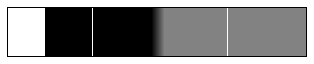

In [24]:
# testimage h-pattern.png (horizontal-pattern?)
img_ve = cv2.imread('images/h-pattern.png', 0); 
plot_img_orig(img_ve)

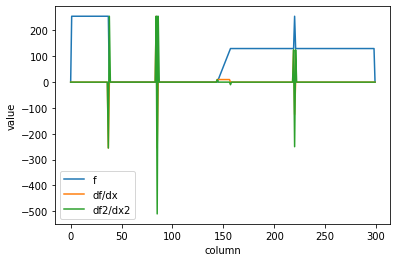

In [25]:
img_ve_d1, img_ve_d2 = compute_derivatives(img_ve)

plt.plot(img_ve[10,:], label='f')
plt.plot(img_ve_d1[10,:], label='df/dx')
plt.plot(img_ve_d2[10,:], label='df2/dx2')

plt.xlabel("column")
plt.ylabel("value")
plt.legend()
plt.show()

sigma = 0:


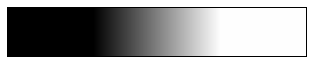

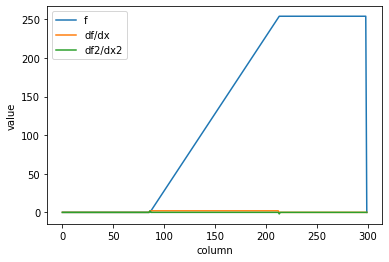

In [26]:
# testimage h-gradient-s00.png (original, sigma = 0)
print("sigma = 0:")
img_s00 = cv2.imread('images/h-gradient-s00.png', 0)
plot_img_orig(img_s00)
img_s00_d1, img_s00_d2 = compute_derivatives(img_s00)

plt.plot(img_s00[10,:], label='f')
plt.plot(img_s00_d1[10,:], label='df/dx')
plt.plot(img_s00_d2[10,:], label='df2/dx2');

plt.xlabel("column") 
plt.ylabel("value") 
plt.legend()
plt.show()

sigma = 1:


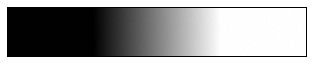

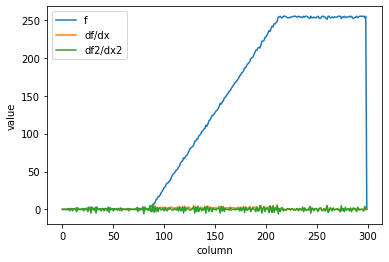

In [27]:
# testimage h-gradient-s01.png (original, sigma = 1)
print("sigma = 1:")
img_s01 = cv2.imread('images/h-gradient-s01.png', 0)
plot_img_orig(img_s01)
img_s01_d1, img_s01_d2 = compute_derivatives(img_s01)

plt.plot(img_s01[10,:], label='f')
plt.plot(img_s01_d1[10,:], label='df/dx')
plt.plot(img_s01_d2[10,:], label='df2/dx2')

plt.xlabel("column")
plt.ylabel("value")
plt.legend()
plt.show()

sigma = 10:


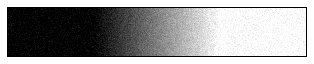

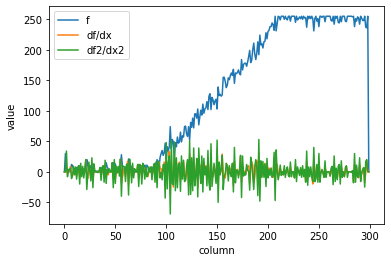

In [28]:
# testimage h-gradient-s10.png (original, sigma = 10)
print("sigma = 10:")
img_s10 = cv2.imread('images/h-gradient-s10.png', 0); 
plot_img_orig(img_s10)

img_s10_d1, img_s10_d2 = compute_derivatives(img_s10)

plt.plot(img_s10[10,:], label='f')
plt.plot(img_s10_d1[10,:], label='df/dx')
plt.plot(img_s10_d2[10,:], label='df2/dx2')

plt.xlabel("column")
plt.ylabel("value")
plt.legend();
plt.show()


sigma = 0, normalized:


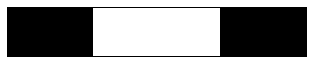

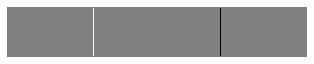

In [29]:
# normalized results
print("sigma = 0, normalized:")
img_s00_d1_n = cv2.normalize(img_s00_d1, None, 0, 255, cv2.NORM_MINMAX)
img_s00_d2_n = cv2.normalize(img_s00_d2, None, 0, 255, cv2.NORM_MINMAX)

plot_img_orig(img_s00_d1_n)
plot_img_orig(img_s00_d2_n)

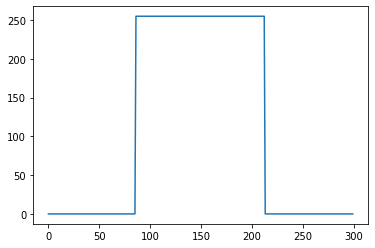

In [30]:
plt.plot(img_s00_d1_n[10,:], label='df/dx')
plt.show()

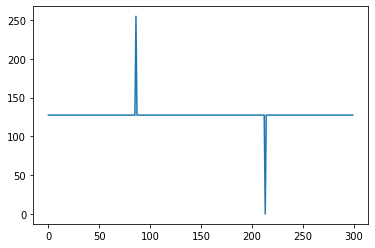

In [31]:
plt.plot(img_s00_d2_n[10,:], label='df2/dx2')
plt.show()

sigma = 1, normalized:


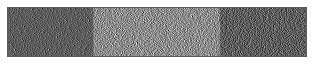

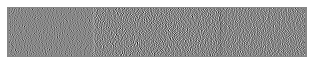

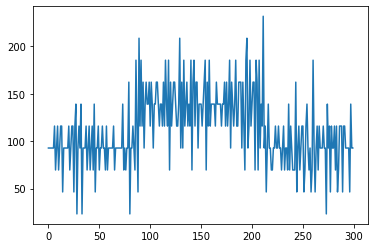

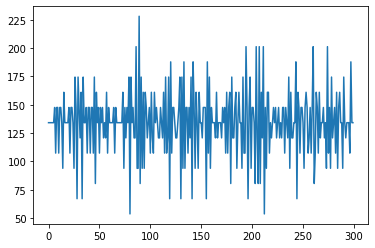

In [32]:
print("sigma = 1, normalized:")
img_s01_d1_n = cv2.normalize(img_s01_d1, None, 0, 255, cv2.NORM_MINMAX)
img_s01_d2_n = cv2.normalize(img_s01_d2, None, 0, 255, cv2.NORM_MINMAX)

plot_img_orig(img_s01_d1_n)
plot_img_orig(img_s01_d2_n)

plt.plot(img_s01_d1_n[10,:], label='df/dx')
plt.show()

plt.plot(img_s01_d2_n[10,:], label='df2/dx2')
plt.show()

sigma = 10, normalized:


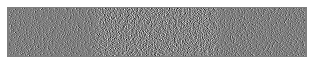

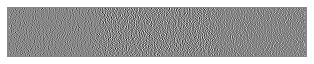

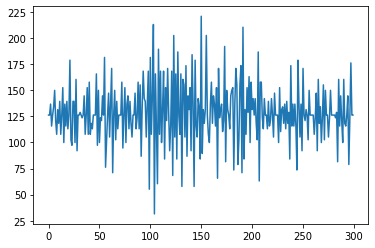

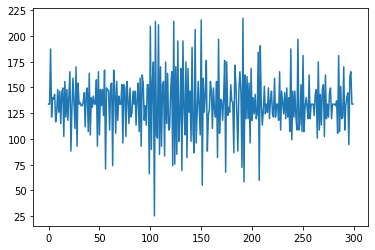

In [33]:
print("sigma = 10, normalized:")
img_s10_d1_n = cv2.normalize(img_s10_d1, None, 0, 255, cv2.NORM_MINMAX)
img_s10_d2_n = cv2.normalize(img_s10_d2, None, 0, 255, cv2.NORM_MINMAX)

plot_img_orig(img_s10_d1_n)
plot_img_orig(img_s10_d2_n)
plt.plot(img_s10_d1_n[10,:], label='df/dx')
plt.show()
plt.plot(img_s10_d2_n[10,:], label='df2/dx2') 
plt.show()

The results confirm the behavior of the derivatives as explained in the lecture notes:

<table>
<tr style="font-weight:bold;">
    <td>Image details</td>
    <td>First-order derivatives</td>
    <td>Second-order derivatives</td>
</tr>
<tr>
    <td>Flat segment</td>
    <td>0</td>
    <td>0</td>
</tr>
<tr>
    <td>Ramp of constant slope</td>
    <td>nonzero</td>
    <td>0</td>
</tr>
<tr>
    <td>Onset and end of discontinuity</td>
    <td>nonzero</td>
    <td>nonzero</td>
</tr>
</table>

The first derivative is constant along a ramp and therefore produce thick edges in such cases. The second derivative produces a double edge at the beginning and end, seperated by zeros, and with opposite signs. Furthermore, they have a stronger response to fine details (especially noise). The second-order derivatives are unacceptably sensitive to noise, which becomes even more important when the images are normalized. Note that normalization is often necessary to be able to work with the output images.